In [1]:
import os
os.chdir("../../../../..")

In [10]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
from umap import UMAP
import seaborn as sns
from sklearn.metrics import silhouette_score
from rdkit import Chem
from scipy.spatial.distance import pdist, squareform

from src.non_euclidean import Wasserstein, REMatch
from src.datasets import QM9Dataset

In [3]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-06-01 08:26:53.262 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-01 08:26:53.686 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-06-01 08:26:53.688 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-06-01 08:26:53.767 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-01 08:30:24.373 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-06-01 08:30:24.408 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-01 08:30:24.442 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

# Experiment 1 isomers seperation experiment

In [4]:
formula_counts = df.group_by("formula").len("count").sort("count", descending=True)

In [ ]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from sklearn.metrics import silhouette_score
from umap import UMAP
from typing import Any, Optional

# Assuming Chem from rdkit, REMatch, and Wasserstein are imported globally

def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F, etc.) and acyclic structures.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    ring_info = mol.GetRingInfo().AtomRings()
    if not ring_info:
        return "Acyclic"
        
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle"
                
    sizes = set(len(ring) for ring in ring_info)
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"


def optimize_rematch_alpha(df: pl.DataFrame, d_w1: np.ndarray) -> float:
    """
    Scans a logarithmic grid of alpha values to maximize topological correlation 
    with the exact W1 distance matrix baseline.
    """
    print("\n[+] Initiating REMatch alpha parameter optimization...")
    rematch = REMatch()
    
    # Extract unique upper-triangular indices to avoid diagonal zeros and redundant pairs
    n_samples = d_w1.shape[0]
    triu_idx = np.triu_indices(n_samples, k=1)
    flat_w1 = d_w1[triu_idx]
    
    # Logarithmic exploration grid spanning your transition window
    alpha_grid = np.logspace(-3.5, 1, num=50)
    
    best_alpha = 0.1
    best_corr = -1.0
    
    for alpha in alpha_grid:
        d_test = rematch.distance_matrix(df, alpha=alpha)
        
        # Skip if the solver encountered non-finite matrices and returned None
        if d_test is None:
            continue
            
        flat_test = d_test[triu_idx]
        corr, _ = pearsonr(flat_test, flat_w1)
        
        print(f" -> Testing alpha = {alpha:.6f} | Pearson Alignment with W1: {corr:.4f}")
        
        if corr > best_corr:
            best_corr = corr
            best_alpha = alpha
            
    print(f"[+] Optimization Complete. Best Alpha: {best_alpha:.6f} (Pearson r = {best_corr:.4f})")
    return float(best_alpha)


def run_strain_topology_comparison(
    df: pl.DataFrame,
    d_euclidean: np.ndarray,
    d_rematch_high: np.ndarray,
    d_rematch_opt: np.ndarray,
    d_w1: np.ndarray,
    d_w2: np.ndarray,
    label_col: str = "ring_category",
    opt_alpha_val: float = 0.1
) -> None:
    """Computes topological summary properties and generates the 5-panel side-by-side UMAP plot."""
    raw_labels = df.get_column(label_col).to_numpy()
    legend_labels = np.where(raw_labels == "3-ring", "Strained (3-Membered)", "Relaxed (6-Membered)")
    unique_classes = np.unique(legend_labels)

    # Dictionary containing the 5 evaluation conditions mapping to your text's variables
    matrices = {
        "Averaged SOAP (Euclidean)": d_euclidean,
        "REMatch (High $\\alpha = 10.0$)": d_rematch_high,
        f"REMatch (Optimized $\\alpha = {opt_alpha_val:.4f}$)": d_rematch_opt,
        "Wasserstein ($W_1$)": d_w1,
        "Wasserstein ($W_2$)": d_w2
    }

    metrics_summary = {}

    # Calculate distance metrics properties in high-dimensional ambient space
    for name, dist_matrix in matrices.items():
        sil = silhouette_score(dist_matrix, legend_labels, metric="precomputed")
        
        intra_dists = []
        for cls in unique_classes:
            idx = np.where(legend_labels == cls)[0]
            sub_matrix = dist_matrix[np.ix_(idx, idx)]
            triu_idx = np.triu_indices(len(idx), k=1)
            intra_dists.append(np.mean(sub_matrix[triu_idx]))
        mean_intra = np.mean(intra_dists)

        idx_strained = np.where(legend_labels == "Strained (3-Membered)")[0]
        idx_relaxed = np.where(legend_labels == "Relaxed (6-Membered)")[0]
        inter_matrix = dist_matrix[np.ix_(idx_strained, idx_relaxed)]
        mean_inter = np.mean(inter_matrix)

        separation_ratio = mean_intra / mean_inter
        metrics_summary[name] = {
            "Silhouette": sil, "Intra-Class": mean_intra, "Inter-Class": mean_inter, "Sep-Ratio": separation_ratio
        }

    print("\n" + "="*115)
    print(f"{'Framework / Metric':<35} | {'Intra-Class (↓)':<15} | {'Inter-Class (↑)':<15} | {'Sep Ratio (↓)':<13} | {'Silhouette (↑)':<12}")
    print("-" * 115)
    for name, m in metrics_summary.items():
        print(f"{name:<35} | {m['Intra-Class']:<15.4f} | {m['Inter-Class']:<15.4f} | {m['Sep-Ratio']:<13.4f} | {m['Silhouette']:<12.4f}")
    print("="*115 + "\n")

    # Expanded plot layout layout to 1 row, 5 columns
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 5, figsize=(30, 6.0), dpi=300)
    palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

    for ax, (name, dist_matrix) in zip(axes, matrices.items()):
        print(f"Computing UMAP projection from precomputed {name} matrix...")

        reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
        umap_coords = reducer.fit_transform(dist_matrix)

        sns.scatterplot(
            x=umap_coords[:, 0], y=umap_coords[:, 1],
            hue=legend_labels, palette=palette, s=90, alpha=0.85,
            edgecolors="#2d3436", linewidths=0.8, ax=ax, zorder=10,
        )

        ax.set_title(name, fontsize=11, fontweight="bold", pad=15)
        ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight="medium")
        ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight="medium")
        ax.grid(True, linestyle=":", alpha=0.6)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
        sns.despine(ax=ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Ring Topology Mapping", title_fontsize=11, fontsize=10,
        loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2,
        frameon=True, facecolor="white", edgecolor="#e2e8f0",
    )

    plt.tight_layout()
    output_filename = "transport_strain_comparison.png"
    print(f"Saved high-res comparison plot to {output_filename}")
    plt.show()


def run_pipeline(df_base: pl.DataFrame):
    """
    Executes structural cleaning, unifies balance allocations across matching
    chemical formulas, optimizes the entropic framework, and generates benchmarks.
    """
    # Step A: Perform RDKit classification
    print("Categorizing rings and enforcing pure carbocycles using RDKit...")
    df_classified = df_base.with_columns(
        pl.col("smiles")
        .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
        .alias("ring_category")
    )

    df_3_rings_all = df_classified.filter(pl.col("ring_category") == "3-ring")
    df_6_rings_all = df_classified.filter(pl.col("ring_category") == "6-ring")

    # Step B: Identify overlapping formula matches
    counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
    counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})
    formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

    formula_overlap = formula_overlap.with_columns(
        pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
    ).sort("max_balanced_size", descending=True)

    if formula_overlap.height == 0:
        raise ValueError("No overlapping pure carbocycle formulas found in this dataset subset.")

    # Step C: Extract best formula matches and balance allocations
    best_row = formula_overlap.row(0, named=True)
    best_formula = best_row["formula"]
    max_size = min(best_row["max_balanced_size"], 100)

    print(f"\nOptimal configuration located: {best_formula}")
    print(f"Sampling balanced sets of size: {max_size}")

    df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
    df_experiment = pl.concat([df_3_sampled, df_6_sampled])

    # Step D: Compute Base Reference Spaces
    print("Computing baseline distance spaces...")
    X_averaged = np.vstack(df_experiment["soap_embedding"].to_list())
    d_euclidean = squareform(pdist(X_averaged, metric="euclidean"))

    wasserstein = Wasserstein()
    d_w1 = wasserstein.distance_matrix(df_experiment, metric='euclidean')
    d_w2 = wasserstein.distance_matrix(df_experiment, metric='sqeuclidean')

    # Step E: Optimize REMatch alpha using W1 baseline references
    optimized_alpha = optimize_rematch_alpha(df=df_experiment, d_w1=d_w1)

    # Step F: Generate bounding evaluation states
    rematch = REMatch()
    print("\nGenerating final distance matrices for comparisons...")
    d_rematch_high = rematch.distance_matrix(df_experiment, alpha=10.0)
    d_rematch_opt = rematch.distance_matrix(df_experiment, alpha=optimized_alpha)
    
    if d_rematch_high is None or d_rematch_opt is None:
        print("Error: REMatch returned non-finite matrices during final evaluation blocks.")
        return

    # Step G: Trigger evaluation summary and plotting
    run_strain_topology_comparison(
        df=df_experiment, 
        d_euclidean=d_euclidean, 
        d_rematch_high=d_rematch_high,
        d_rematch_opt=d_rematch_opt, 
        d_w1=d_w1, 
        d_w2=d_w2, 
        label_col="ring_category",
        opt_alpha_val=optimized_alpha
    )

Categorizing rings and enforcing pure carbocycles using RDKit...


2026-06-03 10:33:09.653 | INFO     | src.non_euclidean:_feature_matrices_from_df:49 - Using column: soap_matrix from df
2026-06-03 10:33:09.677 | INFO     | src.non_euclidean:distance_matrix:205 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: euclidean



Optimal configuration located: C9H16
Sampling balanced sets of size: 27
Computing baseline distance spaces...


Wasserstein distances: 100%|██████████| 54/54 [00:00<00:00, 416.01row/s]
2026-06-03 10:33:09.810 | INFO     | src.non_euclidean:_feature_matrices_from_df:49 - Using column: soap_matrix from df
2026-06-03 10:33:09.822 | INFO     | src.non_euclidean:distance_matrix:205 - Computing Wasserstein distance matrix sequentially | Features: soap | Metric: sqeuclidean
Wasserstein distances: 100%|██████████| 54/54 [00:00<00:00, 356.30row/s]
2026-06-03 10:33:09.981 | INFO     | src.non_euclidean:_feature_matrices_from_df:49 - Using column: soap_matrix from df
2026-06-03 10:33:09.995 | INFO     | src.non_euclidean:_clean_descriptor_matrices:121 - All descriptor matrices are already normalized.
2026-06-03 10:33:09.996 | INFO     | src.non_euclidean:distance_matrix:160 - Computing REMatch kernel distance matrix | Features: soap | Metric: linear | alpha: 0.00031622776601683794



[+] Initiating REMatch alpha parameter optimization...
[3.16227766e-04 3.90693994e-04 4.82695744e-04 5.96362332e-04
 7.36795456e-04 9.10298178e-04 1.12465782e-03 1.38949549e-03
 1.71669791e-03 2.12095089e-03 2.62039853e-03 3.23745754e-03
 3.99982340e-03 4.94171336e-03 6.10540230e-03 7.54312006e-03
 9.31939576e-03 1.15139540e-02 1.42252931e-02 1.75751062e-02
 2.17137430e-02 2.68269580e-02 3.31442475e-02 4.09491506e-02
 5.05919749e-02 6.25055193e-02 7.72244995e-02 9.54095476e-02
 1.17876863e-01 1.45634848e-01 1.79929362e-01 2.22299648e-01
 2.74647411e-01 3.39322177e-01 4.19226744e-01 5.17947468e-01
 6.39915234e-01 7.90604321e-01 9.76778110e-01 1.20679264e+00
 1.49097166e+00 1.84206997e+00 2.27584593e+00 2.81176870e+00
 3.47389211e+00 4.29193426e+00 5.30261134e+00 6.55128557e+00
 8.09400122e+00 1.00000000e+01]


...

 -> Testing alpha = 8.094001 | Pearson Alignment with W1: 0.9099
 -> Testing alpha = 10.000000 | Pearson Alignment with W1: 0.9098
[+] Optimization Complete. Best Alpha: 0.002620 (Pearson r = 0.9963)

Generating final distance matrices for comparisons...


2026-06-03 10:35:26.583 | INFO     | src.non_euclidean:_feature_matrices_from_df:49 - Using column: soap_matrix from df
2026-06-03 10:35:26.598 | INFO     | src.non_euclidean:_clean_descriptor_matrices:121 - All descriptor matrices are already normalized.
2026-06-03 10:35:26.598 | INFO     | src.non_euclidean:distance_matrix:160 - Computing REMatch kernel distance matrix | Features: soap | Metric: linear | alpha: 0.0026203985288583485



Framework / Metric                  | Intra-Class (↓) | Inter-Class (↑) | Sep Ratio (↓) | Silhouette (↑)
-------------------------------------------------------------------------------------------------------------------
Averaged SOAP (Euclidean)           | 0.0840          | 0.0977          | 0.8597        | 0.1287      
REMatch (High $\alpha = 10.0$)      | 0.1019          | 0.1133          | 0.8992        | 0.0985      
REMatch (Optimized $\alpha = 0.0026$) | 0.2201          | 0.2359          | 0.9329        | 0.0669      
Wasserstein ($W_1$)                 | 0.2078          | 0.2258          | 0.9206        | 0.0790      
Wasserstein ($W_2$)                 | 0.0492          | 0.0558          | 0.8823        | 0.1176      

Computing UMAP projection from precomputed Averaged SOAP (Euclidean) matrix...
Computing UMAP projection from precomputed REMatch (High $\alpha = 10.0$) matrix...
Computing UMAP projection from precomputed REMatch (Optimized $\alpha = 0.0026$) matrix...
Comput

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

Saved high-res comparison plot to transport_strain_comparison.png


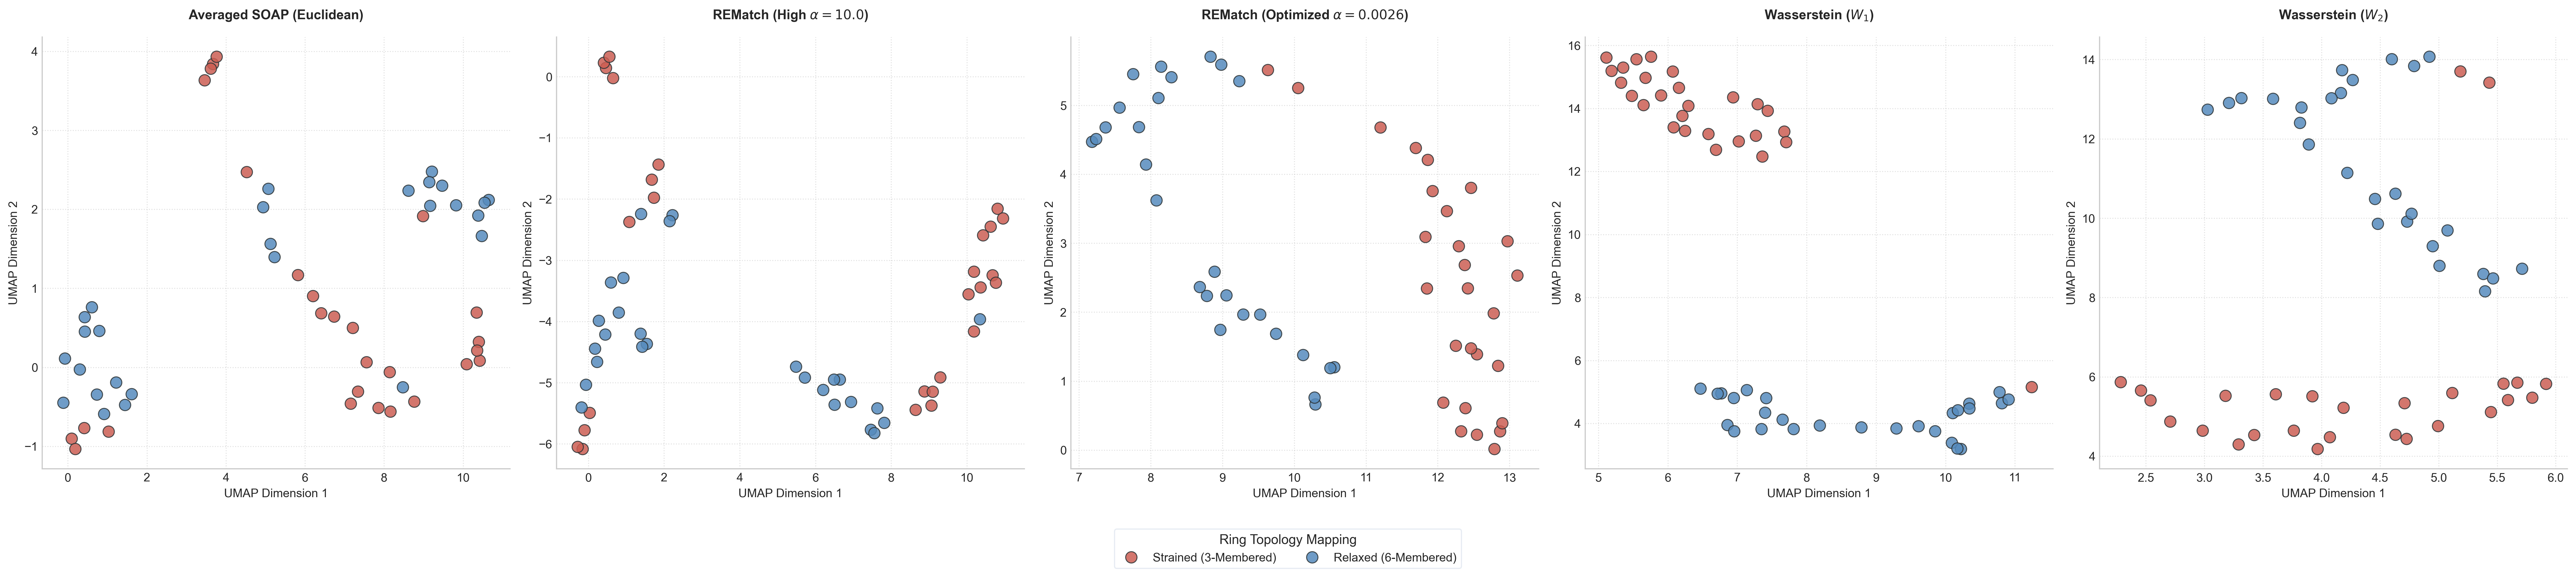

In [43]:
run_pipeline(df)